In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import geopandas as gpd
import rasterio
from rasterio.mask import mask

In [110]:
#loading the classified data
target = gpd.read_file("../data/processed/forest_training.gpkg")

In [3]:
#loading the different spectral bands of the Sentinel-2 data
path_B01 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B01_20m.jp2"
path_B02 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B02_20m.jp2"
path_B03 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B03_20m.jp2"
path_B04 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B04_20m.jp2"
path_B05 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B05_20m.jp2"
path_B06 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B06_20m.jp2"
path_B07 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B07_20m.jp2"
path_B8A = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B8A_20m.jp2"
path_B11 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B11_20m.jp2"
path_B12 = "../data/raw/sattelite/seperate/2018/S2A_MSIL2A_20180919T102021_N0500_R065_T32UPC_20230708T120558.SAFE/GRANULE/L2A_T32UPC_A016936_20180919T102018/IMG_DATA/R20m/T32UPC_20180919T102021_B12_20m.jp2"


def get_image_data(path):

    src = rasterio.open(path)
    data = src.read(1)
    return data, src

In [63]:
data_B01, src_B01 = get_image_data(path_B01)
data_B02, src_B02 = get_image_data(path_B02)
data_B03, src_B03 = get_image_data(path_B03)
data_B04, src_B04 = get_image_data(path_B04)
data_B05, src_B05 = get_image_data(path_B05)
data_B06, src_B06 = get_image_data(path_B06)
data_B07, src_B07 = get_image_data(path_B07)
data_B8A, src_B8A = get_image_data(path_B8A)
data_B11, src_B11 = get_image_data(path_B11)
data_B12, src_B12 = get_image_data(path_B12)

data_B01 = data_B01.reshape(-1,)
data_B02 = data_B02.reshape(-1,)
data_B03 = data_B03.reshape(-1,)
data_B04 = data_B04.reshape(-1,)
data_B05 = data_B05.reshape(-1,)
data_B06 = data_B06.reshape(-1,)
data_B07 = data_B07.reshape(-1,)
data_B8A = data_B8A.reshape(-1,)
data_B11 = data_B11.reshape(-1,)
data_B12 = data_B12.reshape(-1,)

In [64]:
satellite_raw_data = {"B01": data_B01, "B02": data_B02, "B03": data_B03, "B04":data_B04, "B05": data_B05, "B06": data_B06, "B07": data_B07, "B8A":data_B8A, "B11": data_B11, "B12": data_B12}
satellite_df = pd.DataFrame(satellite_raw_data)
satellite_df

,B01,B02,B03,B04,B05,B06,B07,B8A,B11,B12
0,536,1889,2226,2653,2969,3130,3274,3549,4712,4386
1,843,1891,2201,2649,3010,3152,3292,3545,4736,4450
2,1029,1886,2190,2605,2944,3088,3267,3434,4622,4317
3,925,1896,2175,2569,2896,3001,3216,3397,4512,4270
4,815,1858,2122,2541,2833,2991,3146,3371,4534,4284
...,...,...,...,...,...,...,...,...,...,...
30140095,1044,2104,2369,2495,2605,2916,2954,2886,2893,2756
30140096,1107,2428,2496,2424,2404,2427,2460,2467,2578,2380
30140097,1115,2246,2337,2218,2225,2329,2491,2483,2446,2246
30140098,849,1468,1764,1672,2402,2992,3088,3413,2741,2214


In [111]:
#saving all the classified data in a Data Frame for ML
forest_training_df = pd.DataFrame(dtype="Int16")
areas = []

for data, forest_target in zip(target["geometry"], target["class"]):

    single_image_df = pd.DataFrame(dtype="Int16")

    for layer, name in zip([src_B01, src_B02, src_B03, src_B04, src_B05, src_B06, src_B07, src_B8A, src_B11, src_B12], ["B01","B02", "B03", "B04", "B05", "B06", "B07", "B8A", "B11", "B12"]):

        out_image, out_transform = mask(
            layer,
            [data],
            crop=True
        )

        single_image_df[name] = out_image.reshape(-1, )

    single_image_df["Forest"] = forest_target
    areas.append(single_image_df)

forest_training_df = pd.concat(areas, ignore_index=True)

forest_training_df[forest_training_df == 0] = np.nan
forest_training_df = forest_training_df.dropna()
forest_training_df["Forest"] = forest_training_df["Forest"].map({"Forest": 1, "Non-Forest":0})


In [112]:
forest_training_df

,B01,B02,B03,B04,B05,B06,B07,B8A,B11,B12,Forest
350,1387.0,1352.0,1412.0,1348.0,1743.0,2912.0,3398.0,3743.0,2664.0,1820.0,1
351,1383.0,1344.0,1453.0,1366.0,1776.0,3002.0,3426.0,3702.0,2722.0,1831.0,1
352,1383.0,1328.0,1442.0,1339.0,1750.0,3198.0,3707.0,3974.0,2738.0,1809.0,1
353,1381.0,1301.0,1409.0,1335.0,1685.0,3012.0,3630.0,3861.0,2641.0,1741.0,1
354,1378.0,1291.0,1403.0,1310.0,1681.0,2923.0,3490.0,3739.0,2606.0,1732.0,1
...,...,...,...,...,...,...,...,...,...,...,...
454738,1267.0,1298.0,1570.0,1388.0,2041.0,3525.0,4015.0,4368.0,3050.0,2189.0,0
454739,1276.0,1298.0,1560.0,1411.0,2060.0,3603.0,4069.0,4394.0,3063.0,2155.0,0
454740,1294.0,1315.0,1588.0,1414.0,2105.0,3613.0,3926.0,4406.0,3093.0,2190.0,0
454763,1292.0,1318.0,1553.0,1394.0,1965.0,3737.0,4194.0,4554.0,3050.0,2125.0,0


In [83]:
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

In [113]:
#splitting the data in train- and testdata and defining a cross-validation-strategy
X = forest_training_df.drop(columns=["Forest"])
y = forest_training_df["Forest"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, shuffle=True)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

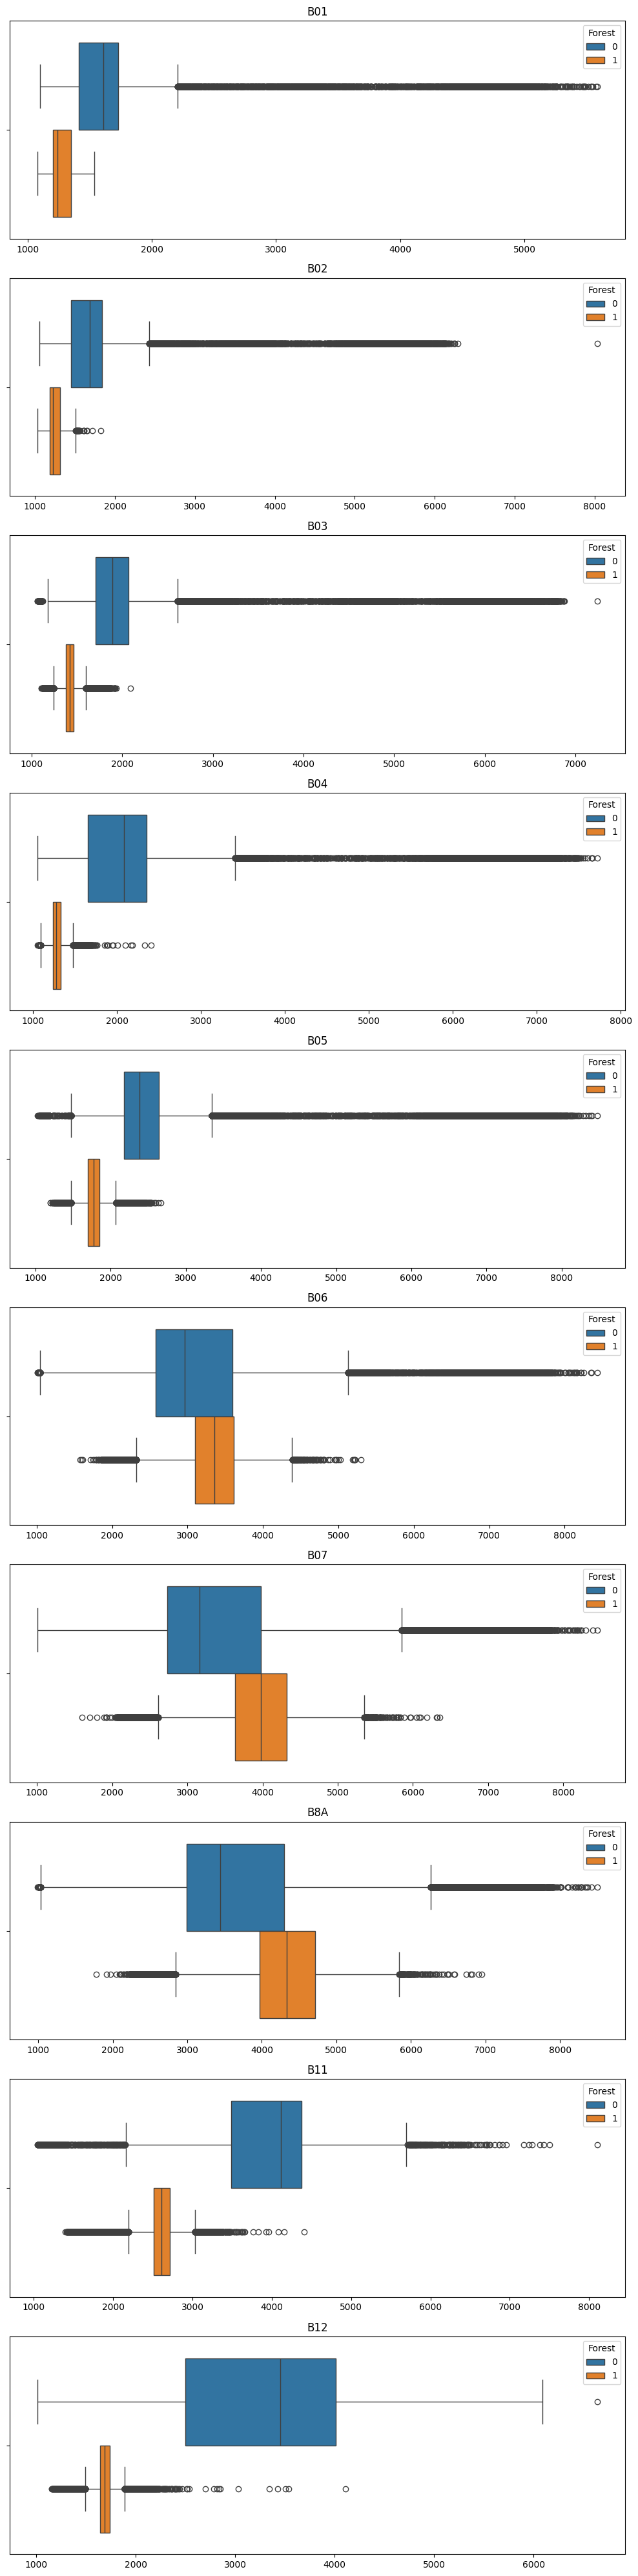

In [114]:
#some plotting
fig, axes = plt.subplots(10, 1, figsize=(10, 40))

for colname, ax in zip(X.columns, axes.ravel()):
    sns.boxplot(X, x=colname, ax=ax, hue=y)
    ax.set_title(colname)
    ax.set_xlabel("")
    
plt.tight_layout()

<Axes: >

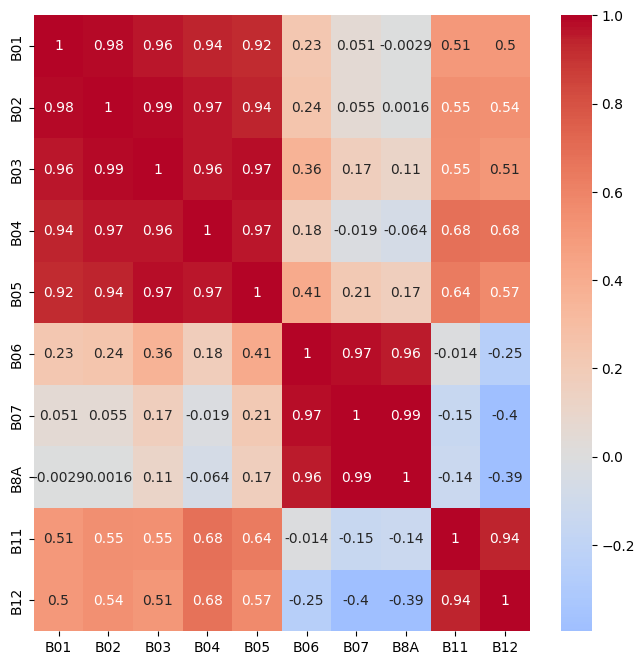

In [115]:
#some more plotting
fig, ax = plt.subplots(figsize = (8, 8))

cont_corr_matrix = X.corr()
sns.heatmap(cont_corr_matrix, annot=True, cmap="coolwarm", center=0)

<Axes: >

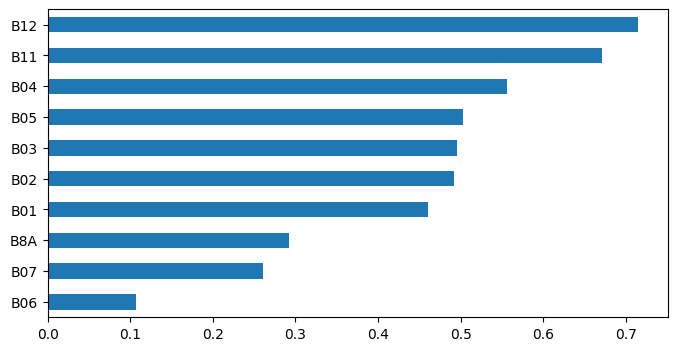

In [116]:
#even some more plotting
fig, ax = plt.subplots(figsize = (8, 4))

cont_target_corr_matrix = X.corrwith(y).abs()
cont_target_corr_matrix.sort_values().plot(kind="barh")

In [ ]:
#evaluating different hyperparameters, but the scikit-learn standard settings are actually pretty good so we keep them
param_grid = {
    "n_estimators": [1, 5, 10, 50, 100],
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 5, 50],
    "max_features": ["sqrt", "log2", None],
}

grid_search_cv = GridSearchCV(
    RandomForestClassifier(random_state=1),
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_search_cv.fit(X_train, y_train)

print("best parameters:", grid_search_cv.best_params_)
print("best cv-score:", grid_search_cv.best_score_)

results = pd.DataFrame(grid_search_cv.cv_results_)
results

In [117]:
#evaluating the test data via cross validation
clf_forest = RandomForestClassifier(
    random_state=1,
    n_jobs=-1
    )

scores = cross_val_score(clf_forest, X_train, y_train, cv=cv, scoring="accuracy")

scores.mean()

np.float64(0.9986681950912187)

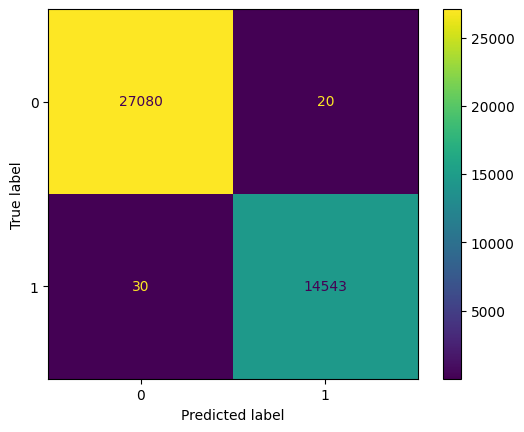

In [118]:
clf_forest.fit(X_train, y_train)
forest_predictions = clf_forest.predict(X_test)

cm = confusion_matrix(
    y_test,
    forest_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot()

#the modell only misclassifies only 1 in a 1000 pixels, which seems amazing
#the 33 missclassified samples might not even be the modells fault but may occur because the samples were classified by hand so there might be a mistake there...

In [119]:
#training the entire modell
clf_forest.fit(X, y)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",1
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total 

In [120]:
#classifying the data by splitting it into chunks
chunk_size = 100000

final_forest_df = pd.DataFrame(dtype="Int16")
chunks = []

for start in range(0, len(satellite_df), chunk_size):

    print(start)

    end = start + chunk_size

    chunk_df = satellite_df.iloc[start:end]
    predictions = clf_forest.predict(chunk_df)
    chunk_df["forest_prediction"] = predictions

    chunks.append(chunk_df)

final_forest_df = pd.concat(chunks, ignore_index=True)

0
100000
200000
300000
400000
500000
600000
700000
800000
900000
1000000
1100000
1200000
1300000
1400000
1500000
1600000
1700000
1800000
1900000
2000000
2100000
2200000
2300000
2400000
2500000
2600000
2700000
2800000
2900000
3000000
3100000
3200000
3300000
3400000
3500000
3600000
3700000
3800000
3900000
4000000
4100000
4200000
4300000
4400000
4500000
4600000
4700000
4800000
4900000
5000000
5100000
5200000
5300000
5400000
5500000
5600000
5700000
5800000
5900000
6000000
6100000
6200000
6300000
6400000
6500000
6600000
6700000
6800000
6900000
7000000
7100000
7200000
7300000
7400000
7500000
7600000
7700000
7800000
7900000
8000000
8100000
8200000
8300000
8400000
8500000
8600000
8700000
8800000
8900000
9000000
9100000
9200000
9300000
9400000
9500000
9600000
9700000
9800000
9900000
10000000
10100000
10200000
10300000
10400000
10500000
10600000
10700000
10800000
10900000
11000000
11100000
11200000
11300000
11400000
11500000
11600000
11700000
11800000
11900000
12000000
12100000
12200000
12300000

In [121]:
final_forest_df["forest_prediction"].value_counts()

forest_prediction
0    23386782
1     6753318
Name: count, dtype: int64

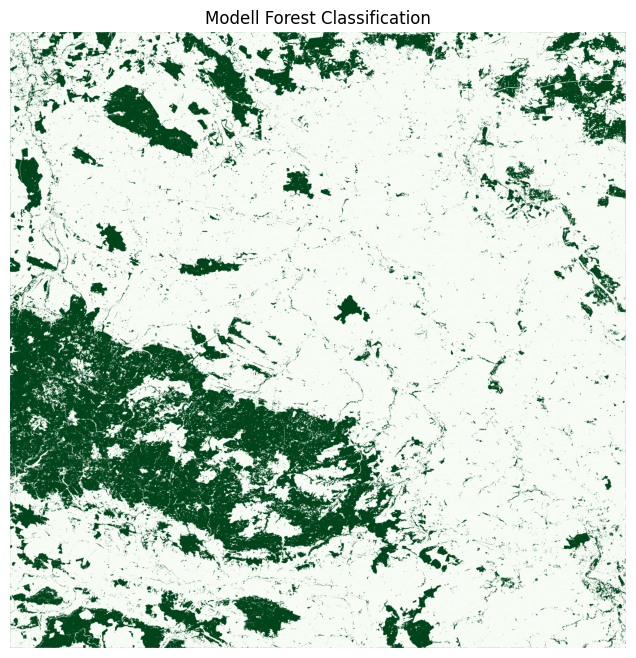

In [122]:
#plotting the results looks really promising
fig, ax = plt.subplots(figsize = (8, 8))

predictions_2d = np.array(final_forest_df["forest_prediction"]).reshape(5490, 5490)

plt.title("Modell Forest Classification")
plt.axis("off")
plt.imshow(predictions_2d, cmap="Greens")

In [123]:
with rasterio.open(
    "../data/processed/forest_classification_2018_R20m.tif",
    "w",
    driver="GTiff",
    height=predictions_2d.shape[0],
    width=predictions_2d.shape[1],
    count=1,
    dtype=predictions_2d.dtype,
    crs=src_B04.crs,
    transform=src_B04.transform
) as dst:

    dst.write(predictions_2d, 1)